In [1]:
import scanpy as sc
import scvi 
import torch
from scvi.external import CellAssign
import pandas as pd
import numpy as np
import scipy
from scipy import sparse

import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))
from src.config import ANALYSIS_DIR, DATA_DIR, FIGURES_DIR, UTILITIES_DIR


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, sys


In [3]:
sc.settings.autosave = True       
sc.settings.figdir = str(FIGURES_DIR / "cell-assign/g6")


In [4]:

g6_dz_clustered = sc.read_h5ad(ANALYSIS_DIR / "clustered_egfDuod_G6_DZ.h5ad")

In [5]:
g6_dz_clustered

## Our 'layers' contains raw 'counts'

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg', 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [6]:
scvi.settings.seed = 0


Seed set to 0


In [7]:
### We import markers of our cell types that are first compiled from Zeve 2022, and Gui Ramos' custom 'Secretory PCs', and 'EE' markers

### Later, we will rerun the analysis with

In [8]:
cell_type_markers = pd.read_csv(UTILITIES_DIR / "cellassign_markers.csv", index_col=0)

### We drop cell markers that aren't expressed in the data




In [9]:
## Working with the 'counts' layer

### Calculate a 'size factor', based on the raw counts. 

In [10]:
lib_size = g6_dz_clustered.layers['counts'].sum(1)
if sparse.issparse(lib_size):
    lib_size = lib_size.A1
g6_dz_clustered.obs["size_factor"] = lib_size / np.mean(lib_size)

In [11]:
filtered_g6 = g6_dz_clustered[:, cell_type_markers.index].copy()

### We drop cell markers that aren't expressed in the data



KeyError: "Values ['ATOH1', 'INSM1', 'NEUROG3', 'PAX4'], from ['ALPI', 'ASCL2', 'ATOH1', 'AXIN2', 'CD44', 'CHGA', 'CHGB', 'DLL1', 'FABP1', 'FABP2', 'FCGBP', 'GFI1', 'INSM1', 'KRT20', 'LGR5', 'MKI67', 'MUC2', 'NEUROD1', 'NEUROG3', 'PAX4', 'PCSK1', 'SOX4'], are not valid obs/ var names or indices."

In [12]:
### We drop cell markers that aren't expressed in the data

cell_type_markers = cell_type_markers.drop(['ATOH1', 'INSM1', 'NEUROG3', 'PAX4'])

filtered_g6 = g6_dz_clustered[:, cell_type_markers.index].copy()


In [13]:
## Make sure that you specify the layer as 'counts'

scvi.external.CellAssign.setup_anndata(filtered_g6, layer="counts", size_factor_key="size_factor")


In [14]:
g6_model = CellAssign(filtered_g6, cell_type_markers)
g6_model.train()

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoa

Epoch 289/400:  72%|███████▏  | 289/400 [07:32<02:53,  1.57s/it, v_num=1, train_loss=5.02]
Monitored metric elbo_validation did not improve in the last 15 records. Best score: 4.942. Signaling Trainer to stop.


<Axes: xlabel='epoch'>

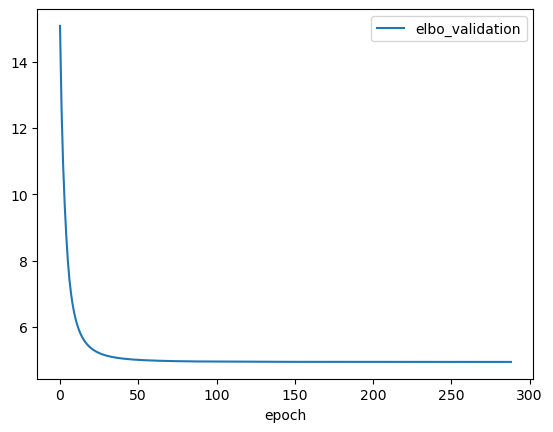

In [15]:
g6_model.history["elbo_validation"].plot()


In [16]:
### Get the cell type predictions

In [17]:
predictions = g6_model.predict()
predictions.head()

,ISCs,PCs,Proliferating PCs,Secretory PCs,Enterocytes,Goblet cells,EECs
0,9.363794e-08,2.098642e-09,1.044995e-12,0.999992,8.272847e-06,4.373815e-11,2.929371e-10
1,5.734069e-06,4.036136e-07,2.218324e-09,0.999004,9.897620e-04,8.725085e-08,4.011530e-07
2,4.954948e-09,1.592150e-12,2.059984e-15,1.000000,3.178762e-08,3.422171e-13,1.955863e-12
3,1.800028e-09,3.448453e-09,3.460024e-08,0.999999,1.382624e-06,1.550669e-11,4.851984e-11
4,2.841986e-06,9.212605e-09,4.552542e-08,0.999931,6.573049e-05,5.122657e-10,2.035335e-09


In [18]:
predictions.describe()

,ISCs,PCs,Proliferating PCs,Secretory PCs,Enterocytes,Goblet cells,EECs
count,7.944800e+04,7.944800e+04,7.944800e+04,79448.000000,7.944800e+04,7.944800e+04,7.944800e+04
mean,2.721174e-04,2.003820e-06,3.588806e-07,0.989805,9.920371e-03,4.491301e-08,7.294081e-08
std,1.336656e-02,2.826588e-04,6.961772e-05,0.092893,9.195350e-02,1.743755e-06,5.605534e-06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2.638431e-37,0.000000e+00,0.000000e+00
25%,4.414117e-08,5.119193e-10,2.331100e-12,0.999603,1.336443e-05,1.123863e-10,5.468088e-10
50%,3.565551e-07,2.680177e-09,1.962665e-11,0.999912,8.561372e-05,7.547354e-10,4.453319e-09
75%,1.969971e-06,1.709093e-08,2.225587e-10,0.999986,3.836997e-04,5.706528e-09,3.100419e-08
max,1.000000e+00,6.048437e-02,1.926483e-02,1.000000,1.000000e+00,2.452720e-04,1.518725e-03


In [19]:
## description of results

In [20]:
## save the dataframe

os.getcwd()
predictions.to_csv(str(ANALYSIS_DIR / "cell_assign_dfs/g6_probabilities.csv"), index=True)

In [21]:

predictions.shape[0], filtered_g6.n_obs
predictions.index[:3], filtered_g6.obs_names[:3]
predictions.index.equals(pd.Index(filtered_g6.obs_names))


False

In [22]:
for col in predictions.columns:
    filtered_g6.obs[f"cell_assign_prob_{col}"] = predictions[col].to_numpy()
filtered_g6.obs["initial_cellassign_prediction"] = predictions.idxmax(axis=1).to_numpy()
filtered_g6.obs["cellassign_confidence"] = predictions.max(axis=1).to_numpy()


In [23]:
filtered_g6.obs

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden,...,_scvi_batch,cell_assign_prob_ISCs,cell_assign_prob_PCs,cell_assign_prob_Proliferating PCs,cell_assign_prob_Secretory PCs,cell_assign_prob_Enterocytes,cell_assign_prob_Goblet cells,cell_assign_prob_EECs,initial_cellassign_prediction,cellassign_confidence
AAACCAAAGATTCCGA-1,G6,6237.0,2697,0,H329,G6,G6,Untreated,G6,11,...,0,9.363794e-08,2.098642e-09,1.044995e-12,0.999992,8.272847e-06,4.373815e-11,2.929371e-10,Secretory PCs,0.999992
AAACCAAAGCATGTAT-1,G6,1475.0,1067,Doublet,Doublet,G6,G6,Untreated,G6,6,...,0,5.734069e-06,4.036136e-07,2.218324e-09,0.999004,9.897620e-04,8.725085e-08,4.011530e-07,Secretory PCs,0.999004
AAACCAAAGCCACGCA-1,G6,3756.0,1831,2,H897,G6,G6,Untreated,G6,9,...,0,4.954948e-09,1.592150e-12,2.059984e-15,1.000000,3.178762e-08,3.422171e-13,1.955863e-12,Secretory PCs,1.000000
AAACCAAAGCCAGCCA-1,G6,9206.0,3324,Doublet,Doublet,G6,G6,Untreated,G6,11,...,0,1.800028e-09,3.448453e-09,3.460024e-08,0.999999,1.382624e-06,1.550669e-11,4.851984e-11,Secretory PCs,0.999999
AAACCAAAGCGAGGTA-1,G6,8202.0,2945,1,H896,G6,G6,Untreated,G6,8,...,0,2.841986e-06,9.212605e-09,4.552542e-08,0.999931,6.573049e-05,5.122657e-10,2.035335e-09,Secretory PCs,0.999931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGGGTCTGT-1,G6,3587.0,1827,2,H897,G6,G6,Untreated,G6,10,...,0,1.139961e-06,2.854286e-09,7.462647e-12,0.999670,3.291870e-04,3.818648e-09,2.186551e-08,Secretory PCs,0.999670
TGTGTTGAGGTAGTGG-1,G6,1605.0,1153,0,H329,G6,G6,Untreated,G6,1,...,0,5.062842e-06,2.783306e-08,3.232219e-10,0.999089,9.054416e-04,6.496275e-08,3.136273e-07,Secretory PCs,0.999089
TGTGTTGAGTACGCCG-1,G6,3563.0,1964,0,H329,G6,G6,Untreated,G6,8,...,0,2.443191e-07,6.133674e-10,1.601266e-12,0.999930,7.017744e-05,8.231671e-10,4.715635e-09,Secretory PCs,0.999930
TGTGTTGAGTGAGGAT-1,G6,4757.0,2222,0,H329,G6,G6,Untreated,G6,7,...,0,5.616974e-07,3.700612e-08,3.096989e-11,0.999792,2.078658e-04,1.546179e-09,9.378159e-09,Secretory PCs,0.999792


In [24]:

cluster_col = "leiden"  

# identify the CellAssign probability columns
prob_cols = [c for c in filtered_g6.obs.columns if c.startswith("cell_assign_prob_")]

# compute per-cluster means
cluster_means = (
    filtered_g6.obs
    .groupby(cluster_col)[prob_cols]
    .mean()
)

print(cluster_means.round(3))  # print nicely rounded


        cell_assign_prob_ISCs  cell_assign_prob_PCs  \
leiden                                                
0                       0.000                   0.0   
1                       0.002                   0.0   
2                       0.000                   0.0   
3                       0.000                   0.0   
4                       0.000                   0.0   
5                       0.000                   0.0   
6                       0.000                   0.0   
7                       0.000                   0.0   
8                       0.000                   0.0   
9                       0.000                   0.0   
10                      0.000                   0.0   
11                      0.000                   0.0   
12                      0.000                   0.0   
13                      0.000                   0.0   

        cell_assign_prob_Proliferating PCs  cell_assign_prob_Secretory PCs  \
leiden                                   

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_4517/1673445497.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_col)[prob_cols]


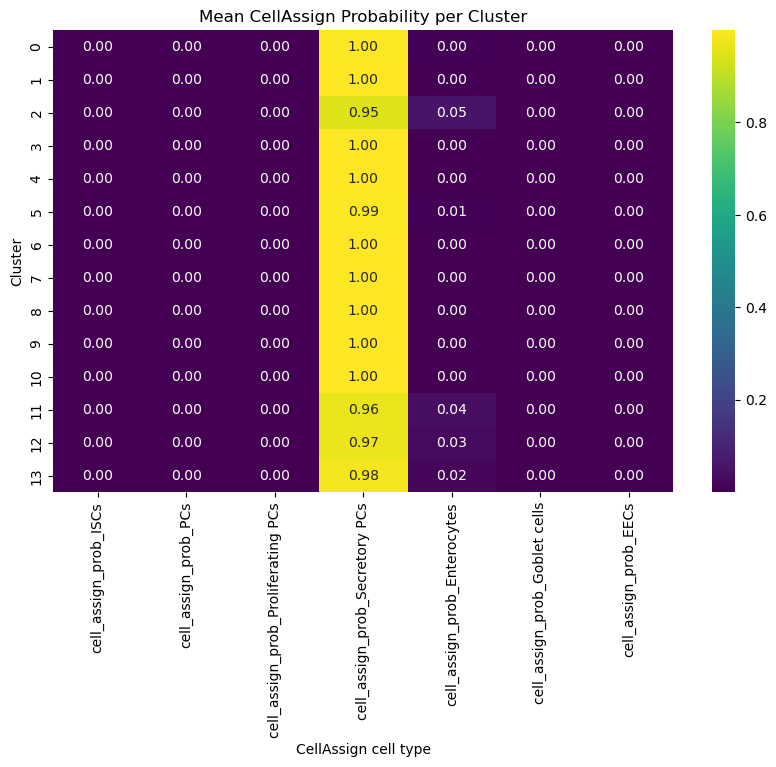

In [25]:


plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, cmap="viridis", annot=True, fmt=".2f")
plt.title("Mean CellAssign Probability per Cluster")
plt.xlabel("CellAssign cell type")
plt.ylabel("Cluster")
plt.show()


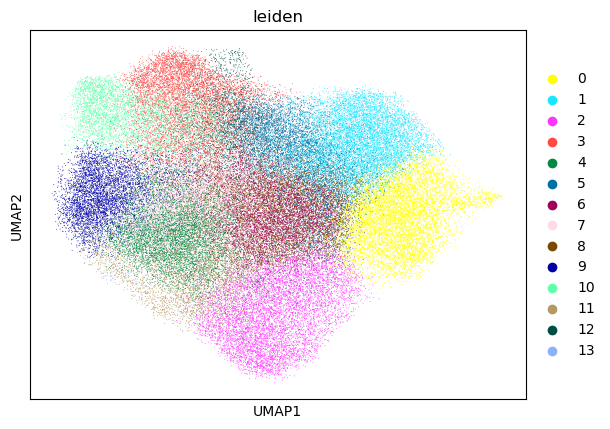

In [26]:
sc.pl.umap(g6_dz_clustered, color = 'leiden', palette=sc.pl.palettes.default_102, save=False # or sc.pl.palettes.zeileis_28
)

In [27]:
## This approach is giving us reasonable labels for clusters 4, 5, and 7:


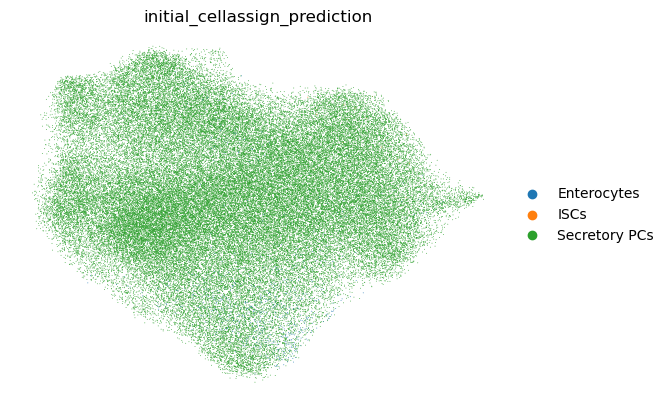

In [28]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    filtered_g6,
    color="initial_cellassign_prediction",
    frameon=False,
    ncols=1,
    save="_g6_dz_initial.pdf"
)

In [29]:
## Let's repeat cell assign, using the DE genes from 'predict5prime'

cell_type_markers = pd.read_csv(UTILITIES_DIR / "cellassign_top10_marker_matrix.csv", index_col=0)
long_filtered_g6 = g6_dz_clustered[:, cell_type_markers.index].copy()
scvi.external.CellAssign.setup_anndata(g6_dz_clustered, layer="counts", size_factor_key="size_factor")


KeyError: "Values ['AIF1', 'C1QA', 'CCL23', 'DEFA6', 'FEV', 'GCG', 'GUCA2A', 'INSL5', 'MS4A12', 'MS4A6A', 'RETNLB', 'TYROBP', 'ZG16'], from ['ADH1C', 'ADH4', 'AIF1', 'ALDOB', 'ALOX5', 'ANXA10', 'APOB', 'AQP8', 'ARHGDIB', 'ASS1', 'AZGP1', 'BEST4', 'BMX', 'C1QA', 'CA1', 'CA2', 'CA4', 'CA7', 'CCL15', 'CCL20', 'CCL23', 'CCL25', 'CD177', 'CD37', 'CD52', 'CD74', 'CEACAM3', 'CEACAM6', 'CEACAM7', 'CHGA', 'CHGB', 'CKB', 'CLCA1', 'CLCA4', 'CORO1A', 'CPVL', 'CRYBA2', 'CTSE', 'CXCL1', 'CXCR4', 'CYP3A4', 'DEFA6', 'DMBT1', 'DNASE1L3', 'DUOX2', 'DUOXA2', 'EDN1', 'FABP1', 'FAM162A', 'FCER1G', 'FCGBP', 'FEV', 'FGL2', 'FN1', 'FOLH1', 'FTH1', 'FYB1', 'GCG', 'GDF15', 'GUCA2A', 'HES1', 'HLA-DPA1', 'HLA-DQA1', 'HLA-DRA', 'HLA-DRB5', 'ICAM2', 'IFITM1', 'IFITM3', 'IGFBP2', 'IL7R', 'INSL5', 'ITLN1', 'KLK1', 'KRT19', 'KRT20', 'KRT8', 'LCN2', 'LEFTY1', 'LGALS4', 'LRMP', 'LTB', 'LYZ', 'MIA', 'MME', 'MS4A12', 'MS4A6A', 'MT1E', 'MT1F', 'MT1G', 'MT1H', 'MT1M', 'MT1X', 'MT2A', 'MTRNR2L12', 'MTRNR2L8', 'MUC2', 'NEURL1

In [30]:
## drop the cell markers not present in the dataset

cell_type_markers = cell_type_markers.drop(index=['AIF1', 'C1QA', 'CCL23', 'DEFA6', 'FEV', 'GCG', 'GUCA2A', 'INSL5', 'MS4A12', 'MS4A6A', 'RETNLB', 'TYROBP', 'ZG16'])


In [31]:
long_filtered_g6 = g6_dz_clustered[:, cell_type_markers.index].copy()
scvi.external.CellAssign.setup_anndata(long_filtered_g6, layer="counts", size_factor_key="size_factor")

In [32]:
extended_g6_model = CellAssign(long_filtered_g6, cell_type_markers)
extended_g6_model.train()

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoa

Epoch 376/400:  94%|█████████▍| 376/400 [1:42:19<06:31, 16.33s/it, v_num=1, train_loss=70.6]
Monitored metric elbo_validation did not improve in the last 15 records. Best score: 70.130. Signaling Trainer to stop.


In [ ]:
long_predictions = extended_g6_model.predict()
long_predictions.head()

,T-Epithelial doublet,Epithelial Progenitor,plasma-epi doublet,Enteroendocrine Cell,Goblet Cells,Early Enterocyte,Late Enterocyte,Tuft Cell,BEST4+ Enterocyte,Myeloid-Epithelial Doublet,REG1A(-) INF-stim prog,Metallothionein-rich Epithelia,M Cell,DUOX2+ Activated Enterocyte,REG1A(+) INF-stim prog,CCL25+ Epithelial Cell,Inflamed Secretory Cells
0,2.163878e-11,4.745359e-30,3.262470e-13,7.089814e-17,1.501990e-09,2.290944e-23,1.995023e-13,3.298515e-18,1.990543e-16,2.338008e-17,0.999878,2.050002e-18,3.197897e-10,6.238583e-08,1.198348e-04,3.406426e-12,1.570320e-14
1,1.540746e-06,1.712238e-12,1.033876e-12,1.039621e-08,1.690032e-05,1.056355e-08,6.581494e-08,1.612200e-08,6.663802e-08,7.640753e-09,0.998555,1.279952e-07,1.659197e-05,2.259674e-14,1.410762e-03,3.095624e-08,2.427369e-12
2,1.824889e-10,5.707851e-18,8.472153e-13,6.713766e-14,3.171338e-12,3.768677e-17,1.444316e-11,4.140408e-17,4.858599e-14,1.201148e-13,0.999504,1.304073e-13,2.397967e-10,9.536351e-09,4.941239e-04,2.716639e-11,3.988928e-14
3,1.185359e-12,3.237189e-23,4.463699e-18,8.288290e-18,3.072014e-08,4.924377e-27,1.884507e-16,1.977534e-15,1.098145e-19,4.085821e-18,0.999962,1.478876e-12,2.146213e-10,9.285538e-08,4.117061e-05,4.804465e-15,3.390252e-17
4,1.672737e-15,1.197276e-24,1.758228e-18,6.514857e-21,3.822596e-10,5.226211e-30,2.439755e-18,3.611474e-20,7.615710e-21,2.646457e-21,1.000000,7.114103e-13,3.600093e-16,2.198180e-12,3.140011e-07,3.491738e-17,7.049008e-18


In [ ]:
for col in long_predictions.columns:
    filtered_g6.obs[f"cell_assign_prob_{col}"] = long_predictions[col].to_numpy()
filtered_g6.obs["extended_cellassign_prediction"] = long_predictions.idxmax(axis=1).to_numpy()


In [ ]:
sns.clustermap(long_predictions, cmap="viridis")


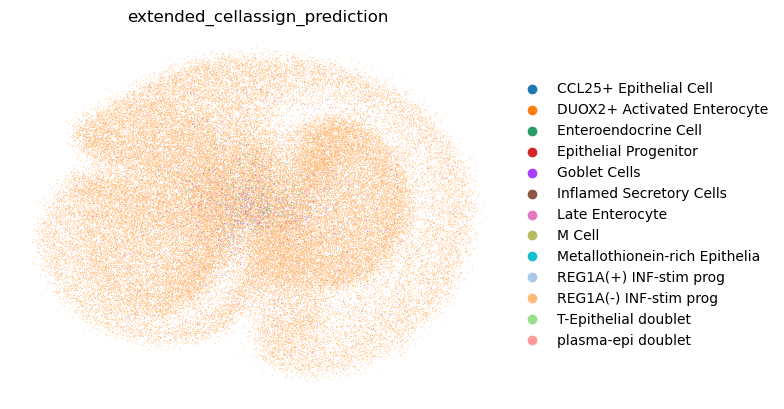

In [ ]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    filtered_g6,
    color="extended_cellassign_prediction",
    frameon=False,
    ncols=1,
    save="_g6_dz_extended.pdf"
)

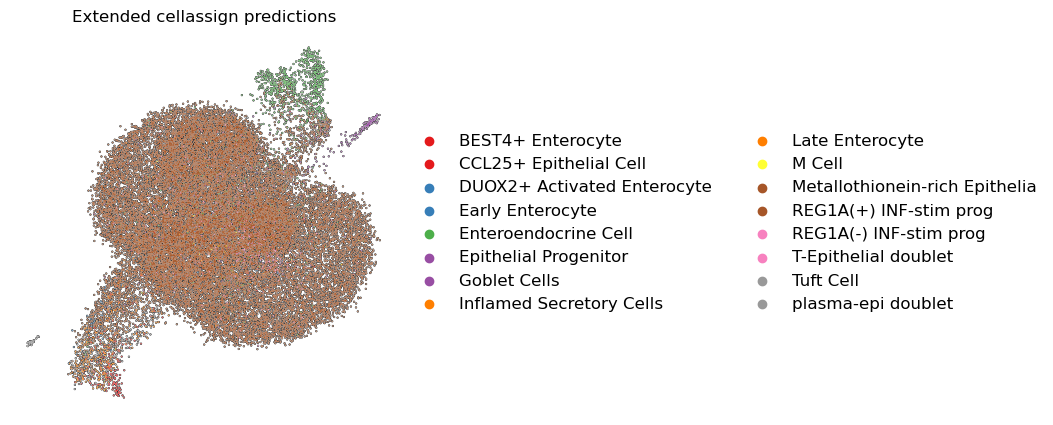

In [ ]:
#from matplotlib.pyplot import rc_context
#
#with rc_context({"figure.figsize": (5, 5)}):
#    sc.pl.umap(
#        filtered_d10_lapa,
#        color="extended_cellassign_prediction",
#        add_outline=True,
#        legend_fontsize=12,
#        legend_fontoutline=2,
#        frameon=False,
#        title="Extended cellassign predictions",
#        palette="Set1",
#    )

In [ ]:
os.getcwd()

'/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'

In [ ]:
sc.write(str(ANALYSIS_DIR / "cellassign_objects/g6_predictions.h5ad"), filtered_g6)